# Analyse des Modèles Binaires

Ce notebook analyse en profondeur les 13 modèles binaires : PCA, matrices de confusion, erreurs, feature importances, courbes ROC.

**Input :** `prepared_data.pkl` + `binary_models.pkl`

## 0. Imports

In [7]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score,
    roc_curve, roc_auc_score
)

BLUE  = '#1F4E79'; LBLUE = '#2E75B6'; GREEN = '#1D9E75'
ORANGE= '#E8A838'; RED   = '#E24B4A'; LGRAY = '#F2F2F2'
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

> **Pourquoi ces imports ?**  
> `roc_curve` et `roc_auc_score` permettent de tracer les courbes ROC — essentielles pour évaluer un classifieur binaire indépendamment du seuil de décision.  
> Les autres imports sont identiques au notebook multi-classe pour cohérence des analyses.

## 1. Chargement des données et des modèles

In [8]:
with open('../DATA_MODELE/prepared_data.pkl', 'rb') as f:
    prepared = pickle.load(f)

with open('../MODELE_SAVE/binary_models.pkl', 'rb') as f:
    bin_data = pickle.load(f)

datasets          = prepared['datasets']
X_raw             = prepared['X_raw']
FEATURE_COLS      = prepared['feature_cols']
models            = bin_data['models']
metrics           = bin_data['metrics']
FEATURE_LABELS    = bin_data['feature_labels']
SUBSTANCE_LABELS  = bin_data['substance_labels']
TARGET_ILLICIT    = bin_data['target_illicit']

print(f'✅ Données chargées')
print(f'   Modèles binaires : {len(models)}')
print(f'   Substances       : {TARGET_ILLICIT}')
print()
for s in TARGET_ILLICIT:
    m = metrics[s]
    print(f'  {s:<14} F1={m["f1"]:.3f} | Recall={m["recall"]:.3f} | '
          f'Précision={m["precision"]:.3f} | ROC-AUC={m["roc_auc"]:.3f}')

✅ Données chargées
   Modèles binaires : 13
   Substances       : ['cannabis', 'benzos', 'ecstasy', 'amphet', 'coke', 'lsd', 'mushrooms', 'legalh', 'amyl', 'meth', 'ketamine', 'heroin', 'vsa']

  cannabis       F1=0.850 | Recall=0.843 | Précision=0.857 | ROC-AUC=0.914
  benzos         F1=0.730 | Recall=0.740 | Précision=0.721 | ROC-AUC=0.796
  ecstasy        F1=0.785 | Recall=0.807 | Précision=0.765 | ROC-AUC=0.848
  amphet         F1=0.787 | Recall=0.812 | Précision=0.763 | ROC-AUC=0.856
  coke           F1=0.763 | Recall=0.802 | Précision=0.727 | ROC-AUC=0.824
  lsd            F1=0.845 | Recall=0.877 | Précision=0.815 | ROC-AUC=0.899
  mushrooms      F1=0.824 | Recall=0.856 | Précision=0.793 | ROC-AUC=0.883
  legalh         F1=0.797 | Recall=0.818 | Précision=0.777 | ROC-AUC=0.865
  amyl           F1=0.770 | Recall=0.813 | Précision=0.732 | ROC-AUC=0.816
  meth           F1=0.783 | Recall=0.816 | Précision=0.752 | ROC-AUC=0.845
  ketamine       F1=0.768 | Recall=0.814 | Précision=0.7

> **Que contient `binary_models.pkl` ?**  
> Pour chaque substance : le modèle Random Forest entraîné, les métriques calculées en validation croisée 5-fold, et les feature importances.  
> Ces métriques sont des **estimations non biaisées** car calculées sur des données que le modèle n'a pas vues lors de l'entraînement.

## 2. PCA — Cercle des corrélations (données brutes)

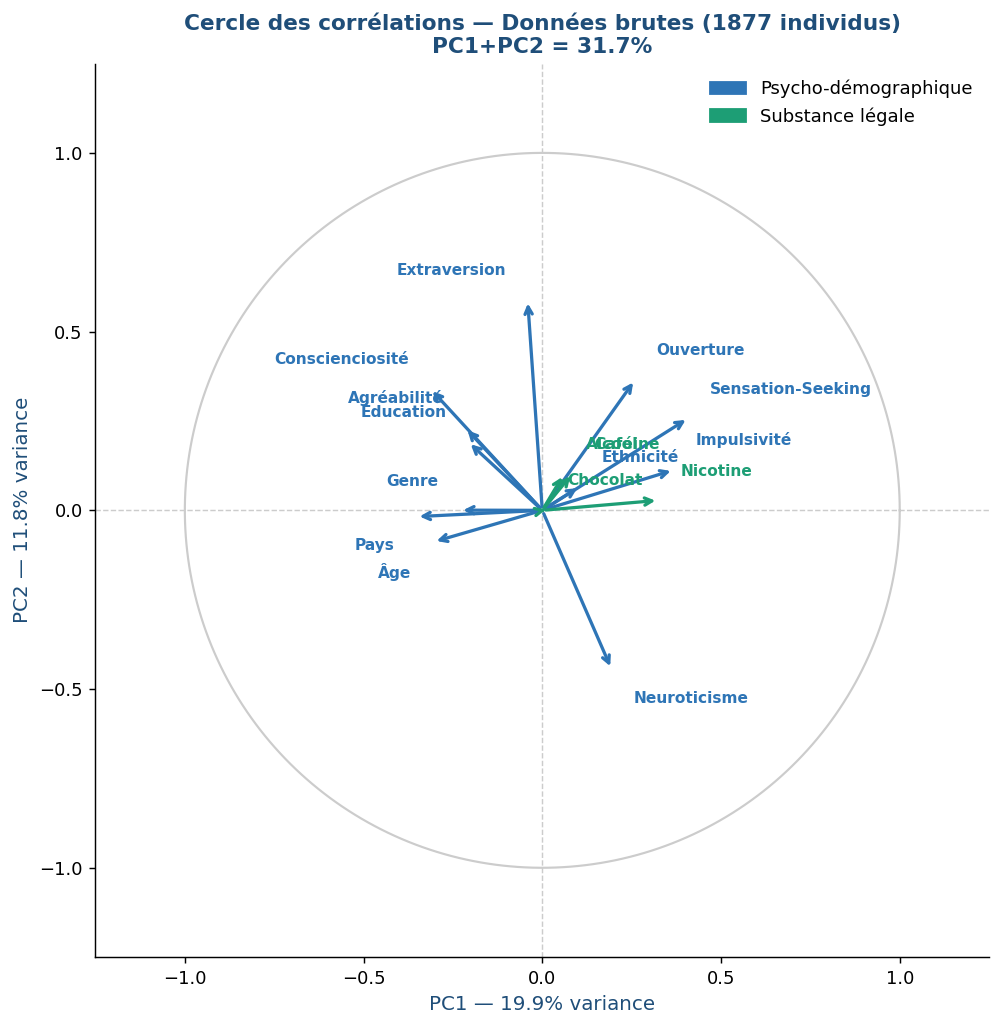

In [9]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
pca      = PCA(n_components=2, random_state=42)
pca.fit(X_scaled)
loadings = pca.components_.T
v1, v2   = pca.explained_variance_ratio_ * 100
is_legal = ['bin' in c for c in FEATURE_COLS]
labels   = [FEATURE_LABELS[c] for c in FEATURE_COLS]

fig, ax = plt.subplots(figsize=(8, 8))
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color='#CCCCCC', linewidth=1.2)
ax.axhline(0, color='#CCCCCC', linewidth=0.8, linestyle='--')
ax.axvline(0, color='#CCCCCC', linewidth=0.8, linestyle='--')

for i, (label, is_l) in enumerate(zip(labels, is_legal)):
    xl, yl = loadings[i,0], loadings[i,1]
    color  = GREEN if is_l else LBLUE
    ax.annotate('', xy=(xl, yl), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    ox = 0.06 if xl>=0 else -0.06
    oy = 0.06 if yl>=0 else -0.06
    ax.text(xl+ox, yl+oy, label, fontsize=8.5, color=color,
            fontweight='bold', ha='left' if xl>=0 else 'right',
            va='bottom' if yl>=0 else 'top')

ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
ax.set_xlabel(f'PC1 — {v1:.1f}% variance', fontsize=11, color=BLUE)
ax.set_ylabel(f'PC2 — {v2:.1f}% variance', fontsize=11, color=BLUE)
ax.set_title(f'Cercle des corrélations — Données brutes (1877 individus)\nPC1+PC2 = {v1+v2:.1f}%',
             fontweight='bold', color=BLUE, fontsize=12)
ax.set_aspect('equal')
p1 = mpatches.Patch(color=LBLUE, label='Psycho-démographique')
p2 = mpatches.Patch(color=GREEN, label='Substance légale')
ax.legend(handles=[p1,p2], frameon=False)
plt.tight_layout()
plt.show()

> **Différence avec le PCA du multi-classe ?**  
> Ici on utilise les **1877 individus bruts** (avant filtrage des consommateurs récents et SMOTE).  
> Cela donne une vision de la structure générale des features sur l'ensemble de la population, pas seulement sur les consommateurs.  
> Les corrélations entre features sont identiques — ce graphique sert de référence commune pour tous les modèles binaires.

## 3. PCA — Séparabilité par substance (avant vs après SMOTE)

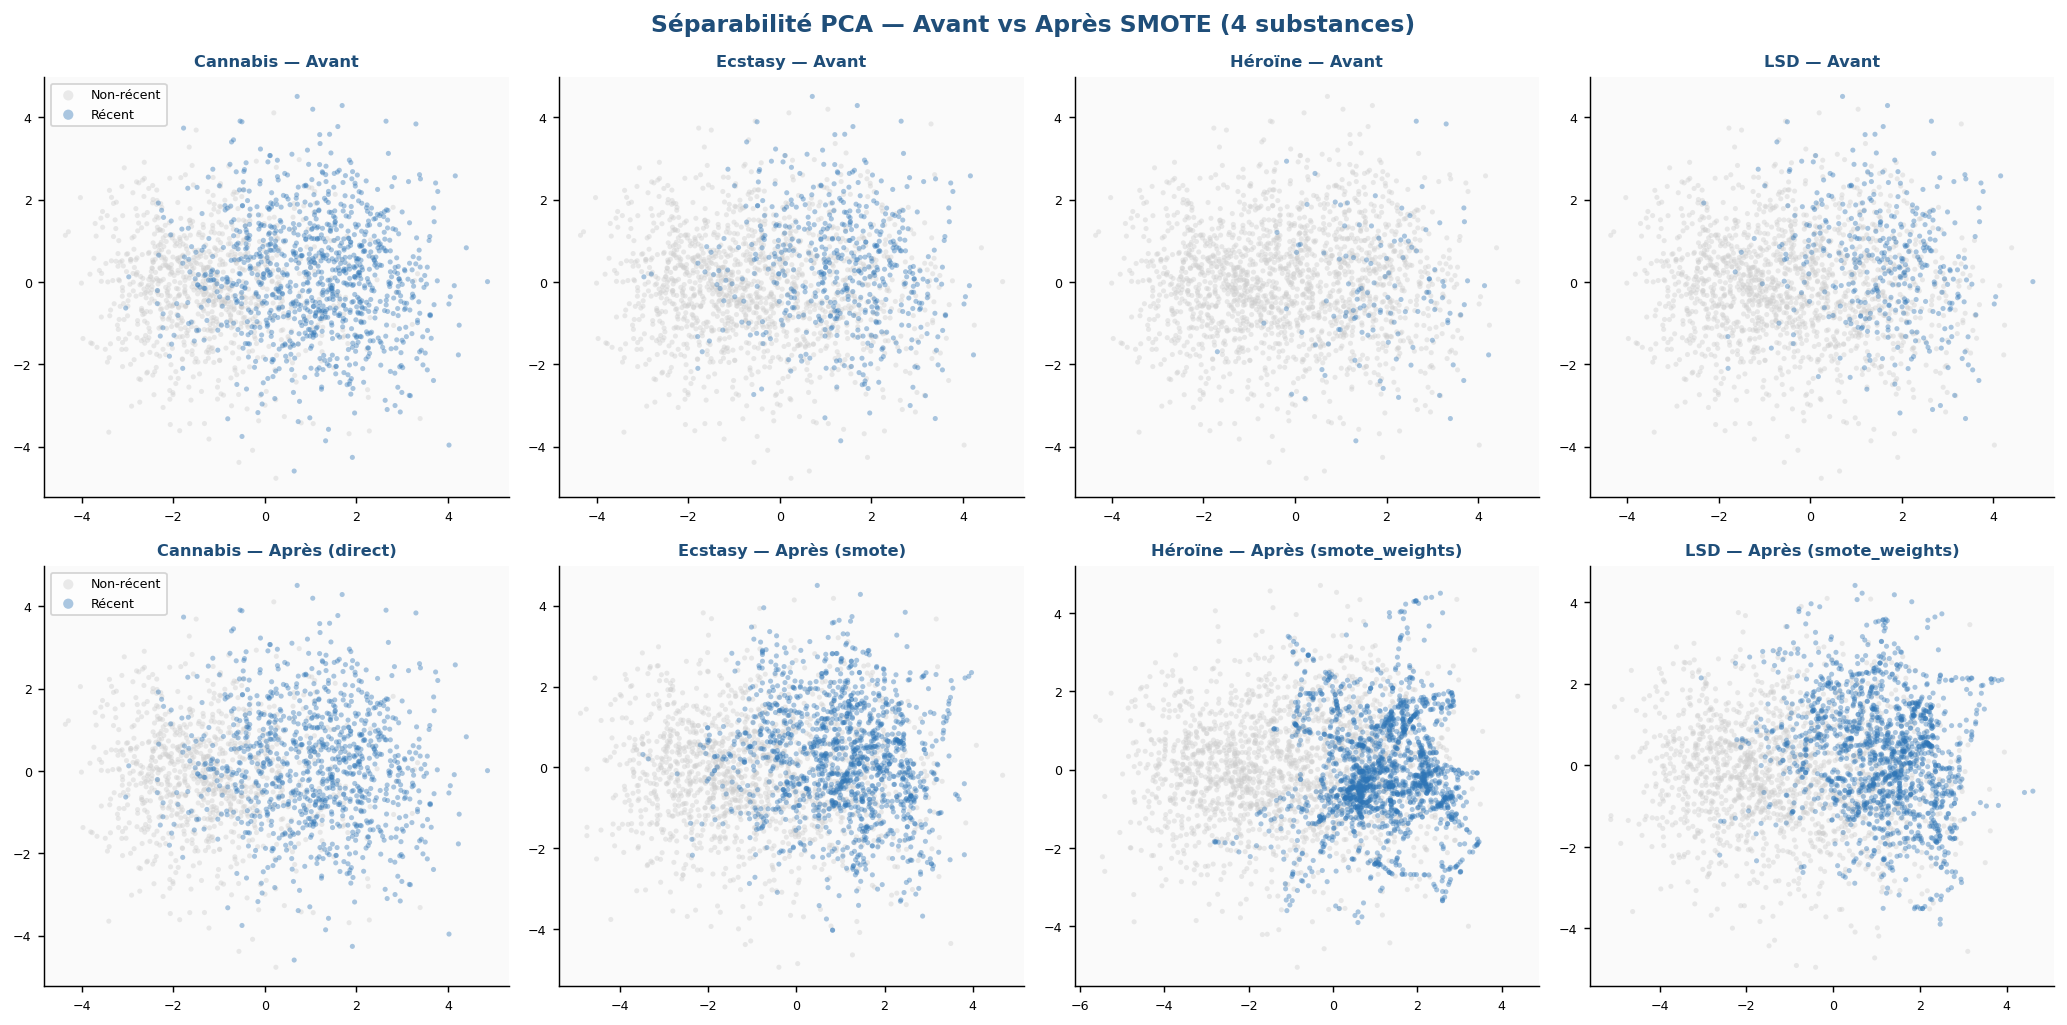

In [10]:
# Visualisation pour 4 substances représentatives
substances_focus = ['cannabis', 'ecstasy', 'heroin', 'lsd']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Séparabilité PCA — Avant vs Après SMOTE (4 substances)',
             fontweight='bold', color=BLUE, fontsize=13)

for col, substance in enumerate(substances_focus):
    X_r = datasets[substance]['X']
    y_r = datasets[substance]['y']
    strat = datasets[substance]['strategy']

    for row, (X_plot, y_plot, title_suffix) in enumerate([
        (X_raw, (X_raw @ np.zeros(16)).astype(int), 'Avant'),  # placeholder
        (X_r,   y_r, f'Après ({strat})')
    ]):
        ax = axes[row, col]
        # Recalcul PCA pour ce dataset
        sc = StandardScaler().fit_transform(X_plot)
        p  = PCA(n_components=2, random_state=42).fit_transform(sc)

        if row == 0:
            # Avant : on reconstruit y depuis X_raw
            RECENT_CLS = ['CL3','CL4','CL5','CL6']
            y_before   = prepared['df'][substance].isin(RECENT_CLS).astype(int).values
            y_plot     = y_before

        for cls, color, label in [
            (0, '#CCCCCC', 'Non-récent'),
            (1, LBLUE,     'Récent')
        ]:
            mask = y_plot == cls
            ax.scatter(p[mask,0], p[mask,1], c=color, s=8, alpha=0.4,
                       edgecolors='none', label=label)

        ax.set_title(f'{SUBSTANCE_LABELS.get(substance,substance)} — {title_suffix}',
                     fontsize=9, fontweight='bold', color=BLUE)
        ax.tick_params(labelsize=7)
        ax.set_facecolor('#FAFAFA')
        if col == 0:
            ax.legend(fontsize=7, frameon=True, markerscale=2)

plt.tight_layout()
plt.show()

> **Pourquoi comparer avant et après SMOTE ?**  
> Avant SMOTE, les classes sont déséquilibrées — on voit peu de points "récent" pour les substances rares.  
> Après SMOTE, les deux classes sont équilibrées et les nouveaux points synthétiques sont visibles.  
> Ce graphique vérifie que le SMOTE ne crée pas de points aberrants hors de la distribution naturelle — les nouveaux points doivent rester dans des zones cohérentes avec les données originales.

## 4. Courbes ROC — Tous les modèles

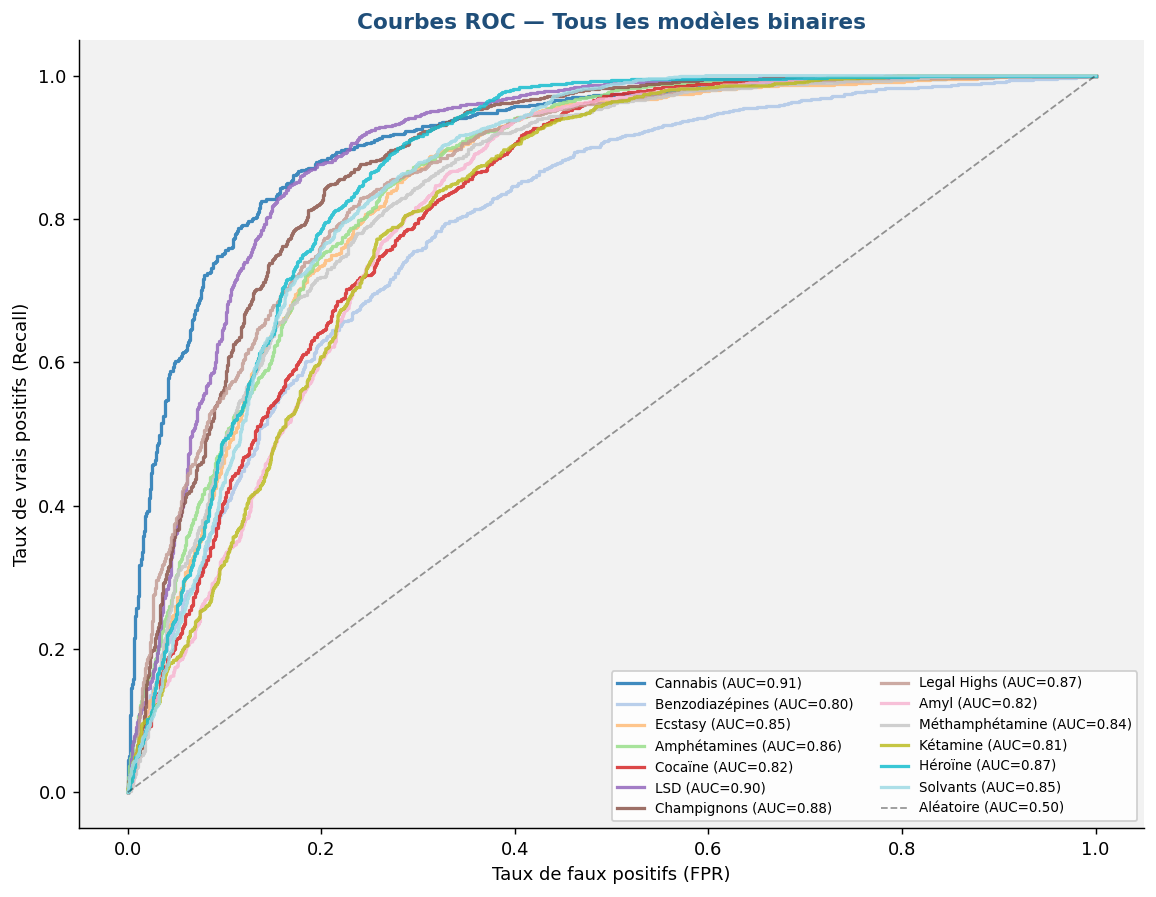

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(9, 7))
palette = plt.cm.tab20(np.linspace(0, 1, len(TARGET_ILLICIT)))

for i, substance in enumerate(TARGET_ILLICIT):
    X_r = datasets[substance]['X']
    y_r = datasets[substance]['y']
    model = models[substance]

    y_proba = cross_val_predict(model, X_r, y_r, cv=cv, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_r, y_proba)
    auc = roc_auc_score(y_r, y_proba)

    ax.plot(fpr, tpr, linewidth=1.8, color=palette[i], alpha=0.85,
            label=f'{SUBSTANCE_LABELS.get(substance,substance)} (AUC={auc:.2f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.4, label='Aléatoire (AUC=0.50)')
ax.set_xlabel('Taux de faux positifs (FPR)', fontsize=10)
ax.set_ylabel('Taux de vrais positifs (Recall)', fontsize=10)
ax.set_title('Courbes ROC — Tous les modèles binaires',
             fontweight='bold', color=BLUE, fontsize=12)
ax.legend(fontsize=7.5, frameon=True, framealpha=0.9,
          loc='lower right', ncol=2)
ax.set_facecolor(LGRAY)
plt.tight_layout()
plt.show()

> **Pourquoi les courbes ROC ?**  
> Une courbe ROC montre le compromis entre recall (détecter tous les vrais consommateurs) et taux de faux positifs (déclencher des fausses alarmes), pour **tous les seuils de décision possibles**.  
> Une courbe proche du coin supérieur gauche = modèle excellent. La diagonale = modèle aléatoire.  
> L'**AUC** (aire sous la courbe) est indépendante du seuil choisi — c'est la métrique la plus robuste pour comparer des modèles, surtout avec du déséquilibre de classes.

## 5. Matrices de confusion — Toutes les substances

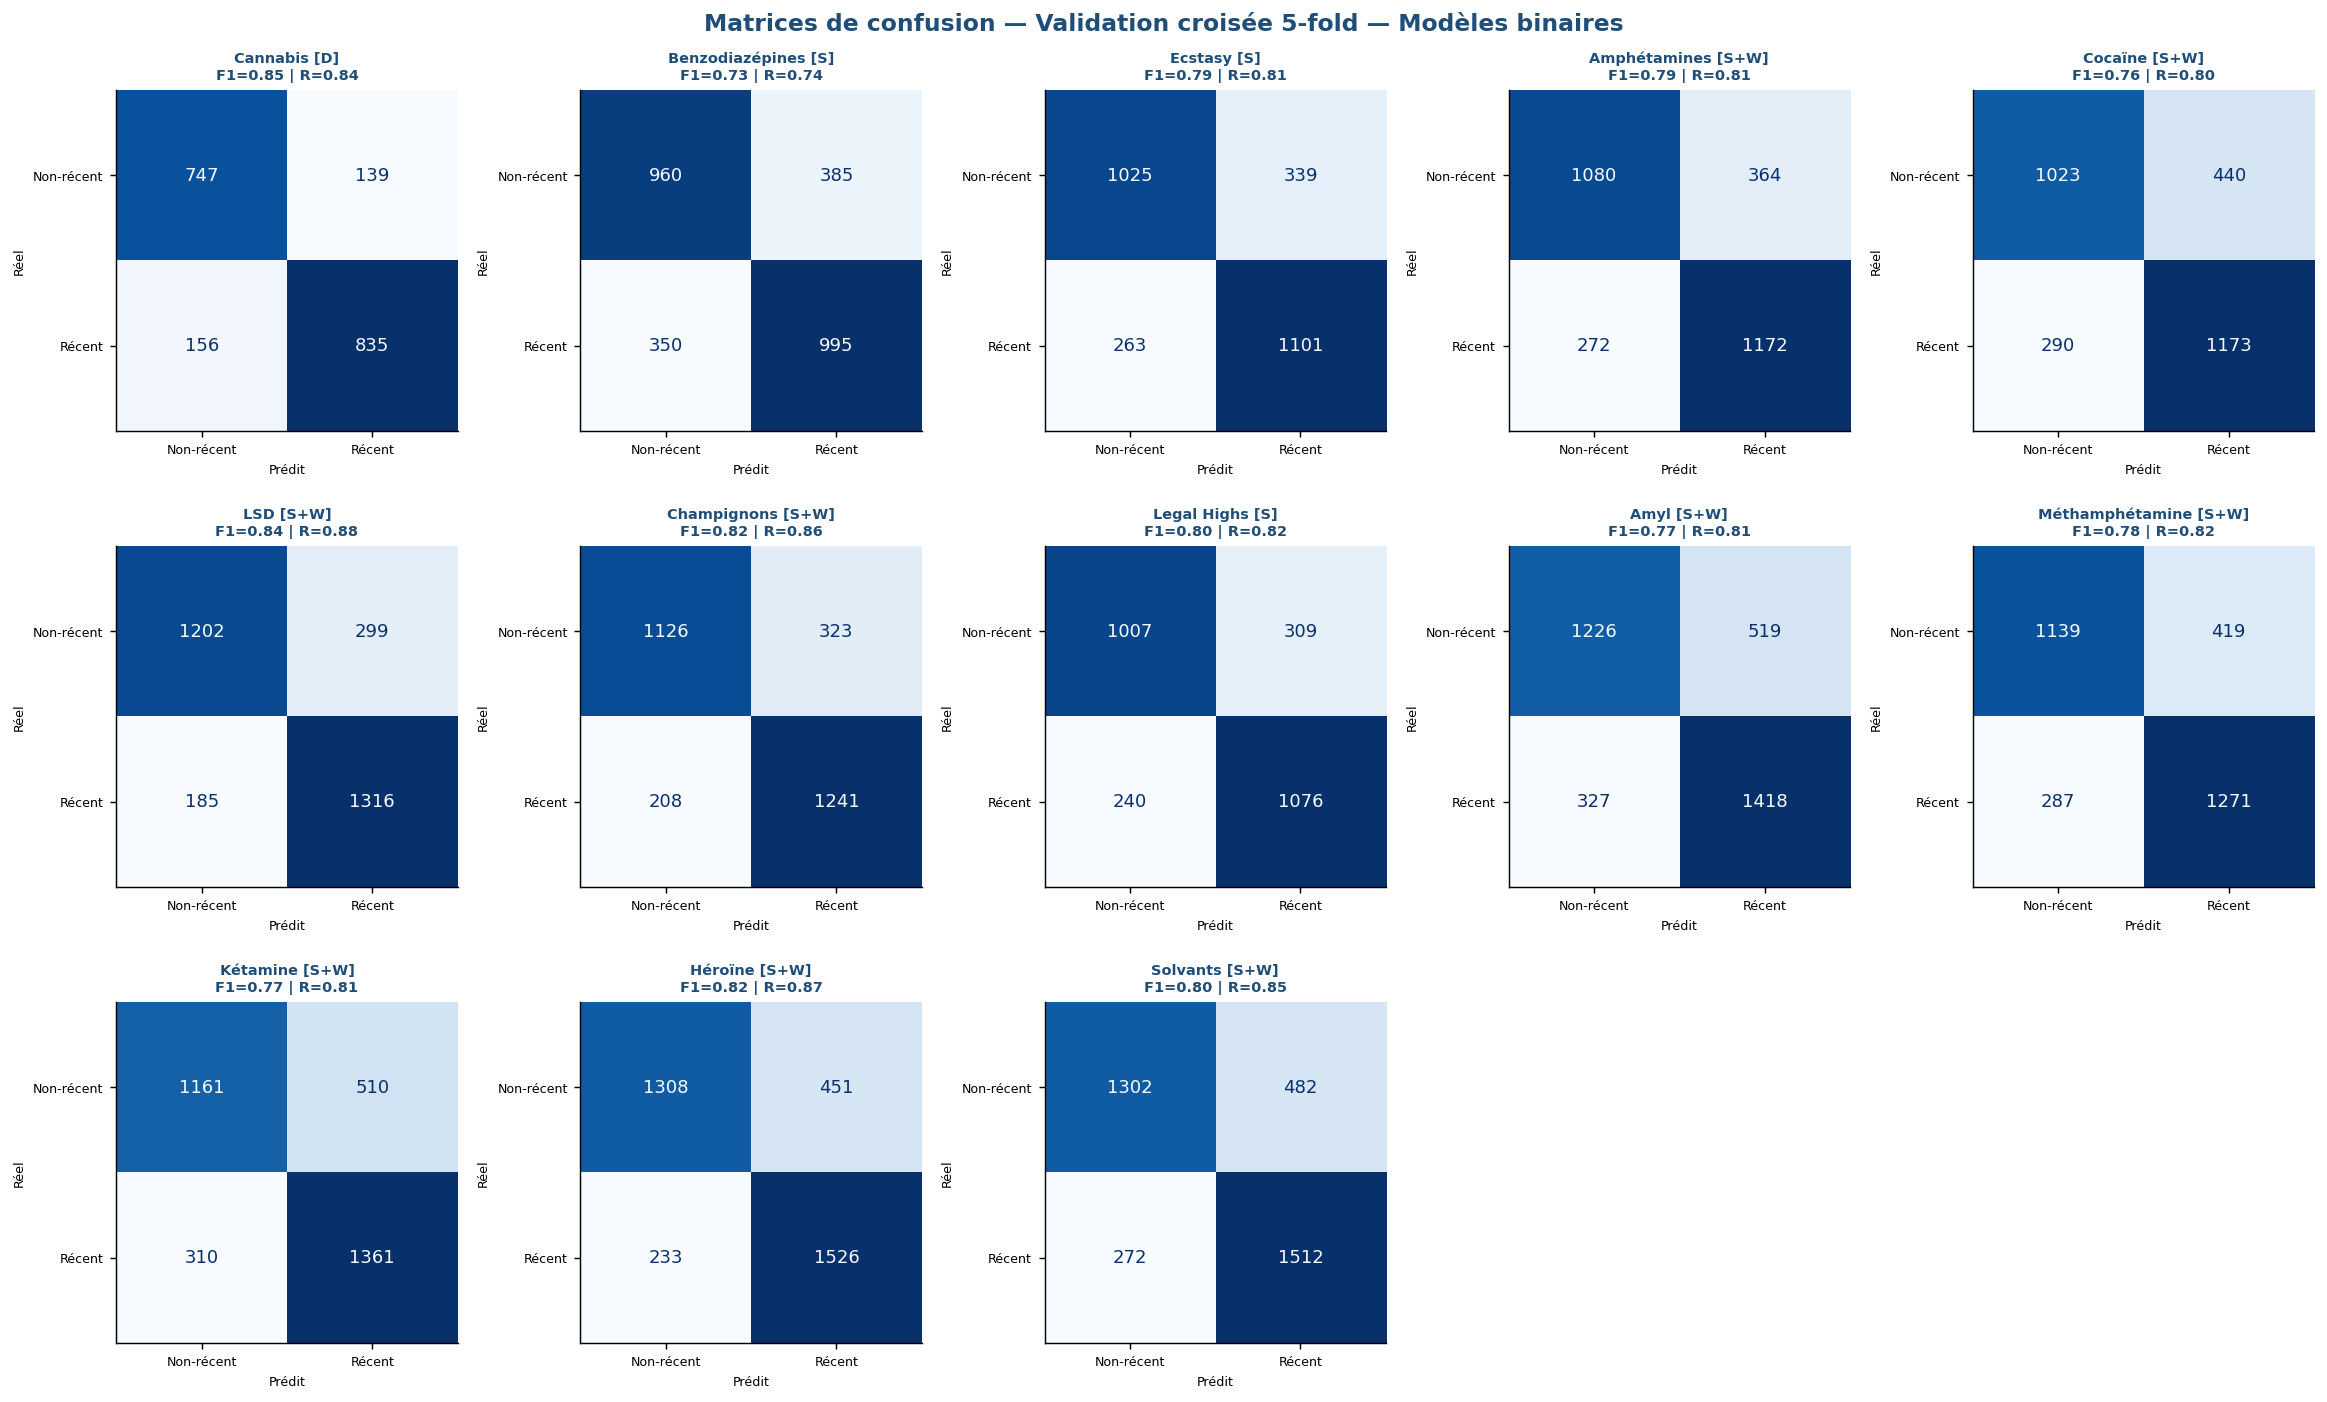

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
fig.suptitle('Matrices de confusion — Validation croisée 5-fold — Modèles binaires',
             fontweight='bold', color=BLUE, fontsize=13)
axes = axes.flatten()

for i, substance in enumerate(TARGET_ILLICIT):
    X_r   = datasets[substance]['X']
    y_r   = datasets[substance]['y']
    model = models[substance]
    strat = datasets[substance]['strategy']

    y_pred = cross_val_predict(model, X_r, y_r, cv=cv)
    cm     = confusion_matrix(y_r, y_pred)
    tn, fp, fn, tp = cm.ravel()
    f1_val = f1_score(y_r, y_pred, zero_division=0)
    rec    = recall_score(y_r, y_pred, zero_division=0)

    ax = axes[i]
    ConfusionMatrixDisplay(cm, display_labels=['Non-récent','Récent']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    strat_map = {'direct':'D','smote':'S','smote_weights':'S+W'}
    ax.set_title(
        f'{SUBSTANCE_LABELS.get(substance,substance)} [{strat_map[strat]}]\n'
        f'F1={f1_val:.2f} | R={rec:.2f}',
        fontsize=8, color=BLUE, fontweight='bold'
    )
    ax.set_xlabel('Prédit', fontsize=7)
    ax.set_ylabel('Réel', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(len(TARGET_ILLICIT), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

> **Comment lire ces matrices ?**  
> Pour chaque substance : en haut à gauche = vrais négatifs (bien classés non-consommateurs), en bas à droite = vrais positifs (bien classés consommateurs), en haut à droite = faux positifs (non-consommateurs classés à tort comme consommateurs), en bas à gauche = **faux négatifs** (consommateurs manqués — l'erreur la plus grave en contexte médical).  
> Le label `[D]` = Direct, `[S]` = SMOTE, `[S+W]` = SMOTE + class_weight.

## 6. Comparaison Recall vs Précision

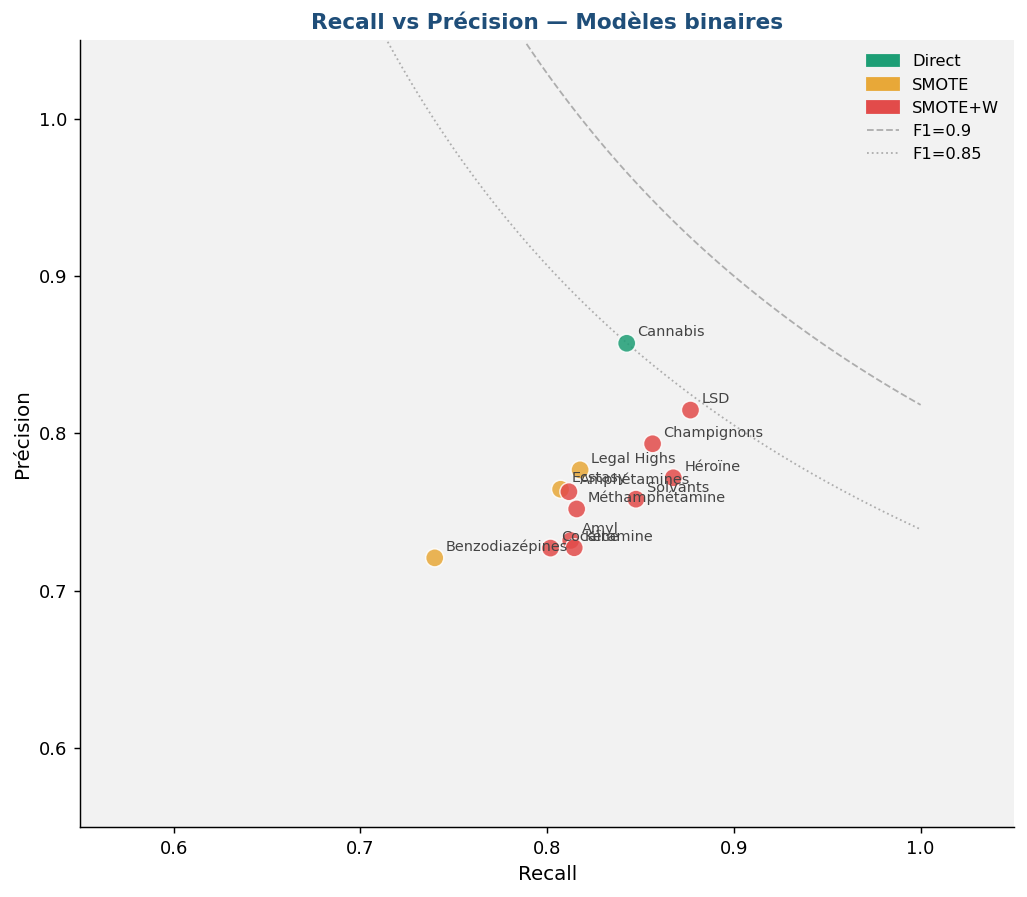

In [13]:
strat_pal = {'direct': GREEN, 'smote': ORANGE, 'smote_weights': RED}
recalls    = [metrics[s]['recall']    for s in TARGET_ILLICIT]
precisions = [metrics[s]['precision'] for s in TARGET_ILLICIT]
colors_pt  = [strat_pal[metrics[s]['strategy']] for s in TARGET_ILLICIT]
labels_pt  = [SUBSTANCE_LABELS.get(s,s) for s in TARGET_ILLICIT]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(recalls, precisions, c=colors_pt, s=100, alpha=0.85,
           edgecolors='white', linewidths=0.8, zorder=3)
for i, label in enumerate(labels_pt):
    ax.annotate(label, (recalls[i], precisions[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=8, color='#444')

# Courbe iso-F1
for f1_val, ls in [(0.90, '--'), (0.85, ':')]:
    x_line = np.linspace(0.6, 1.0, 200)
    y_line = f1_val * x_line / (2*x_line - f1_val)
    mask   = (y_line > 0) & (y_line <= 1.05)
    ax.plot(x_line[mask], y_line[mask], ls, color='gray',
            linewidth=1, alpha=0.6, label=f'F1={f1_val}')

ax.set_xlim(0.55, 1.05); ax.set_ylim(0.55, 1.05)
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Précision', fontsize=11)
ax.set_title('Recall vs Précision — Modèles binaires',
             fontweight='bold', color=BLUE, fontsize=12)
ax.set_facecolor(LGRAY)
patches = [
    mpatches.Patch(color=GREEN,  label='Direct'),
    mpatches.Patch(color=ORANGE, label='SMOTE'),
    mpatches.Patch(color=RED,    label='SMOTE+W'),
]
ax.legend(handles=patches + ax.get_lines(), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

> **Que cherche-t-on sur ce graphique ?**  
> Les points **en haut à droite** ont à la fois un recall et une précision élevés — ce sont les modèles les plus performants.  
> Les courbes pointillées sont des **iso-F1** : tous les points sur une même courbe ont le même F1-score.  
> Un point au-dessus de F1=0.90 = excellent. En dessous de F1=0.85 = à surveiller.  
> Les points vers la gauche signalent des modèles qui **manquent des consommateurs** (recall faible) — problématique en contexte médical.

## 7. Feature importances comparées — Top substances

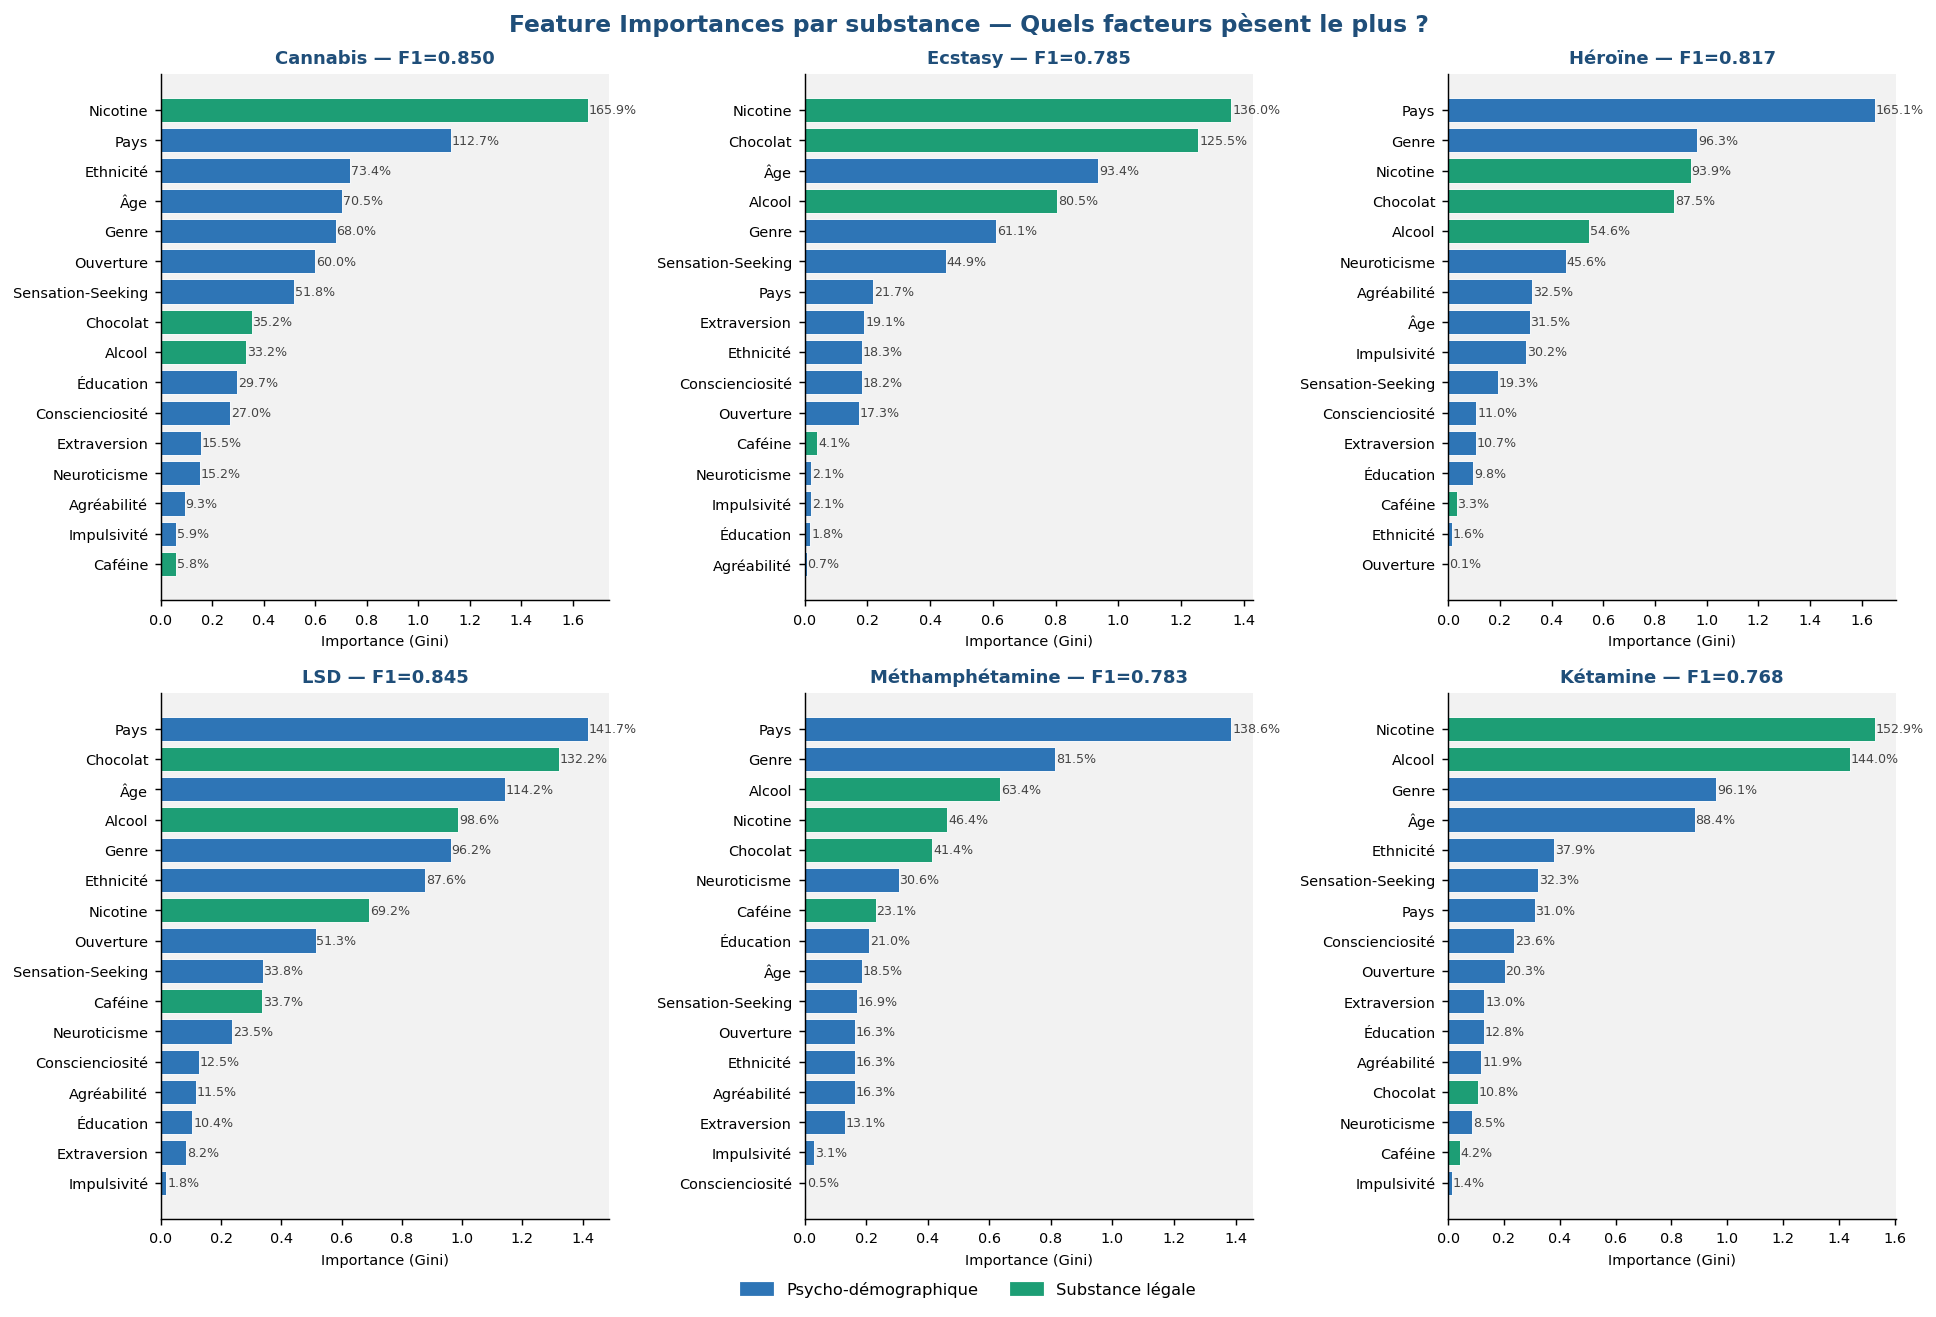

In [14]:
substances_focus = ['cannabis', 'ecstasy', 'heroin', 'lsd', 'meth', 'ketamine']
labels_feat      = [FEATURE_LABELS[c] for c in FEATURE_COLS]
is_legal         = ['bin' in c for c in FEATURE_COLS]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Importances par substance — Quels facteurs pèsent le plus ?',
             fontweight='bold', color=BLUE, fontsize=13)
axes = axes.flatten()

for i, substance in enumerate(substances_focus):
    importances = np.abs(np.array(metrics[substance]['coefficients']))
    idx_sorted  = np.argsort(importances)
    colors_imp  = [GREEN if is_legal[j] else LBLUE for j in idx_sorted]

    ax = axes[i]
    bars = ax.barh(np.array(labels_feat)[idx_sorted], importances[idx_sorted],
                   color=colors_imp, edgecolor='white', linewidth=0.5)
    for bar, j in zip(bars, idx_sorted):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f'{importances[j]*100:.1f}%', va='center', fontsize=7, color='#444')

    f1_val = metrics[substance]['f1']
    ax.set_title(
        f'{SUBSTANCE_LABELS.get(substance,substance)} — F1={f1_val:.3f}',
        fontweight='bold', color=BLUE, fontsize=10
    )
    ax.set_xlabel('Importance (Gini)', fontsize=8)
    ax.set_facecolor(LGRAY)
    ax.tick_params(labelsize=8)

p1 = mpatches.Patch(color=LBLUE, label='Psycho-démographique')
p2 = mpatches.Patch(color=GREEN, label='Substance légale')
fig.legend(handles=[p1,p2], frameon=False, fontsize=9,
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

> **Pourquoi les importances diffèrent-elles d'une substance à l'autre ?**  
> Chaque substance a ses propres patterns psychologiques. Les consommateurs de LSD sont souvent caractérisés par une ouverture élevée, ceux d'héroïne par un neuroticisme élevé et une conscienciosité faible, etc.  
> Ces différences de feature importances montrent que **chaque modèle a appris quelque chose de spécifique** à la substance — c'est une validation indirecte que l'architecture "un modèle par substance" est justifiée par rapport à un modèle unique.

## 8. Tableau récapitulatif des performances

In [15]:
strat_map = {'direct':'🟢 Direct','smote':'🟡 SMOTE','smote_weights':'🔴 SMOTE+W'}

rows = []
for s in TARGET_ILLICIT:
    m = metrics[s]
    rows.append({
        'Substance':  SUBSTANCE_LABELS.get(s, s),
        'Stratégie':  strat_map.get(m['strategy'], m['strategy']),
        'F1-Score':   round(m['f1'], 3),
        'Recall':     round(m['recall'], 3),
        'Précision':  round(m['precision'], 3),
        'ROC-AUC':    round(m['roc_auc'], 3),
    })

df_summary = pd.DataFrame(rows).sort_values('F1-Score', ascending=False)

# Mise en forme
def highlight(val):
    if isinstance(val, float):
        if val >= 0.92: return 'color: #1D9E75; font-weight: bold'
        elif val >= 0.85: return 'color: #E8A838'
        else: return 'color: #E24B4A'
    return ''

print('Performances des modèles binaires (triées par F1 décroissant) :')
print()
print(df_summary.to_string(index=False))
print()
print(f'F1 moyen    : {df_summary["F1-Score"].mean():.3f}')
print(f'Recall moyen: {df_summary["Recall"].mean():.3f}')
print(f'AUC moyen   : {df_summary["ROC-AUC"].mean():.3f}')

Performances des modèles binaires (triées par F1 décroissant) :

      Substance Stratégie  F1-Score  Recall  Précision  ROC-AUC
       Cannabis  🟢 Direct     0.850   0.843      0.857    0.914
            LSD 🔴 SMOTE+W     0.845   0.877      0.815    0.899
    Champignons 🔴 SMOTE+W     0.824   0.856      0.793    0.883
        Héroïne 🔴 SMOTE+W     0.817   0.868      0.772    0.868
       Solvants 🔴 SMOTE+W     0.800   0.848      0.758    0.854
    Legal Highs   🟡 SMOTE     0.797   0.818      0.777    0.865
   Amphétamines 🔴 SMOTE+W     0.787   0.812      0.763    0.856
        Ecstasy   🟡 SMOTE     0.785   0.807      0.765    0.848
Méthamphétamine 🔴 SMOTE+W     0.783   0.816      0.752    0.845
           Amyl 🔴 SMOTE+W     0.770   0.813      0.732    0.816
       Kétamine 🔴 SMOTE+W     0.768   0.814      0.727    0.813
        Cocaïne 🔴 SMOTE+W     0.763   0.802      0.727    0.824
Benzodiazépines   🟡 SMOTE     0.730   0.740      0.721    0.796

F1 moyen    : 0.794
Recall moyen: 0.82

> **Comment utiliser ce tableau ?**  
> Il donne une vue synthétique de la **fiabilité de chaque modèle**.  
> Les modèles avec F1 > 0.92 sont très fiables — leurs prédictions dans le Streamlit sont de haute confiance.  
> Les modèles avec F1 < 0.85 demandent plus de prudence — leurs probabilités doivent être interprétées avec davantage de réserve.  
> Ces informations sont directement utilisées dans le Streamlit pour afficher le niveau de confiance associé à chaque prédiction.